In [1]:
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Load latest backtest log (or set path manually)
LOG_FILE = sorted(glob.glob('imc-prosperity-4-backtester/backtests/*.log'))[-1]
print('Loading:', LOG_FILE)

with open(LOG_FILE) as f:
    data = json.load(f)

# --- Parse activitiesLog (market bid/ask/mid) ---
from io import StringIO
activities = pd.read_csv(StringIO(data['activitiesLog']), sep=';')
activities['timestamp'] = activities['timestamp'].astype(int)

# --- Parse lambdaLog (own orders) ---
# Structure: [compressed_state, orders, conversions, trader_data, logs]
# orders = [[symbol, price, qty], ...]
own_orders = []
for entry in data['logs']:
    raw = entry['lambdaLog']
    if not raw:
        continue
    parsed = json.loads(raw)
    ts = parsed[0][0]
    for symbol, price, qty in parsed[1]:
        own_orders.append({'timestamp': ts, 'symbol': symbol, 'price': price, 'qty': qty})

orders_df = pd.DataFrame(own_orders)
print(f'Activities rows: {len(activities)}  |  Own orders: {len(orders_df)}')
print('Products:', activities['product'].unique())

Loading: imc-prosperity-4-backtester/backtests/2026-04-16_15-24-20.log
Activities rows: 60000  |  Own orders: 55300
Products: ['INTARIAN_PEPPER_ROOT' 'ASH_COATED_OSMIUM']


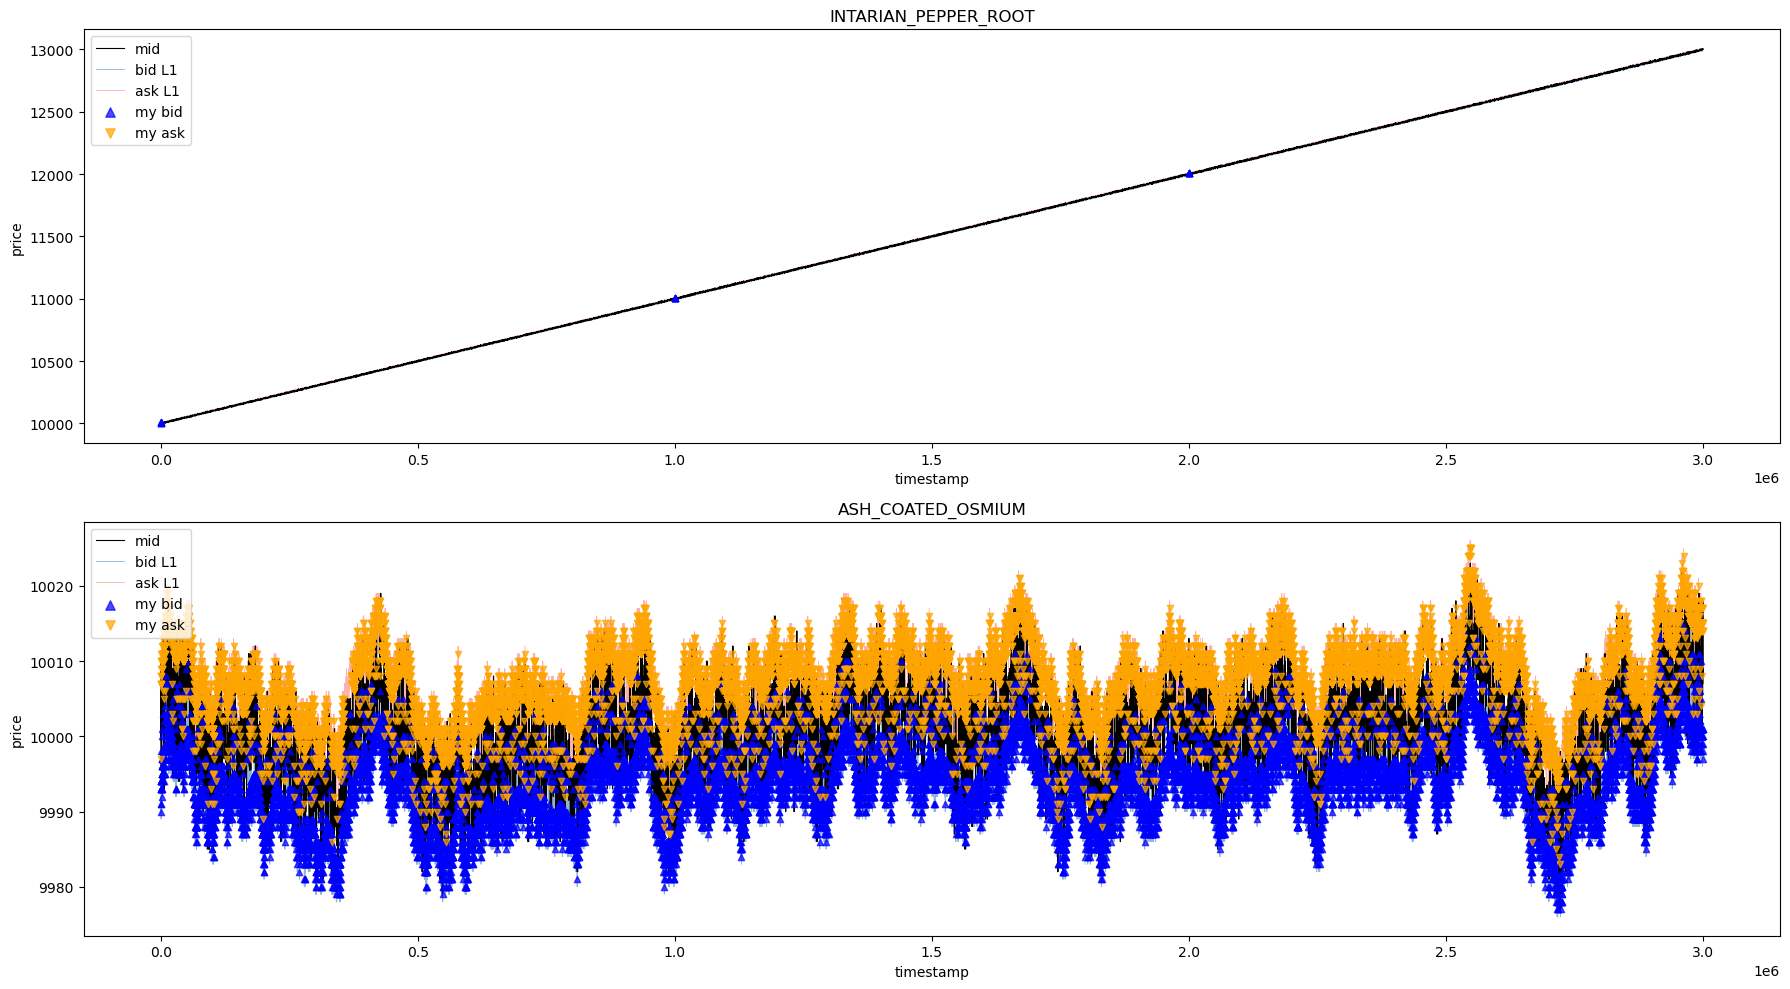

In [3]:
PRODUCTS = activities['product'].unique()
fig, axes = plt.subplots(len(PRODUCTS), 1, figsize=(18, 5 * len(PRODUCTS)), sharex=False)
if len(PRODUCTS) == 1:
    axes = [axes]

for ax, product in zip(axes, PRODUCTS):
    mkt = activities[activities['product'] == product].copy()
    # replace 0s with NaN so missing prices don't draw lines to the floor
    for col in ['bid_price_1', 'ask_price_1', 'mid_price']:
        mkt[col] = mkt[col].replace(0, float('nan'))

    ax.plot(mkt['timestamp'], mkt['mid_price'], lw=0.8, color='black', label='mid', zorder=3)
    ax.plot(mkt['timestamp'], mkt['bid_price_1'], lw=0.6, color='steelblue', alpha=0.6, label='bid L1')
    ax.plot(mkt['timestamp'], mkt['ask_price_1'], lw=0.6, color='salmon', alpha=0.6, label='ask L1')

    if len(orders_df) > 0:
        prod_orders = orders_df[orders_df['symbol'] == product]
        buys  = prod_orders[prod_orders['qty'] > 0]
        sells = prod_orders[prod_orders['qty'] < 0]
        ax.scatter(buys['timestamp'],  buys['price'],  marker='^', s=20, color='blue',   alpha=0.7, zorder=4, label='my bid')
        ax.scatter(sells['timestamp'], sells['price'], marker='v', s=20, color='orange', alpha=0.7, zorder=4, label='my ask')

    ax.set_title(product)
    ax.set_ylabel('price')
    ax.set_xlabel('timestamp')
    ax.legend(loc='upper left', markerscale=1.5)

plt.tight_layout()
plt.show()